# #1 Clusters and Markers

## Purpose

Combine data from all embryos, get highly-variable genes, perform clustering, and identify marker genes for each cluster.

## Setup

In [ ]:
import scanpy as sc
import treedata as td
import cupy as cp
import scipy as sp
import rapids_singlecell as rsc
import rmm
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from devmap.config import get_paths

base_path, plots_path, results_path = get_paths("annotation")
reference_path = base_path / "reference"
data_path = base_path / "data"

GPU configuration

In [2]:
rmm.reinitialize(
    managed_memory=True,  # Allows oversubscription
    pool_allocator=False,  # default is False
    devices=0,  # GPU device IDs to register. By default registers only GPU 0.
)
cp.cuda.set_allocator(rmm.allocators.cupy.rmm_cupy_allocator)

## Helper functions

In [3]:
def tdata_concat(tdatas):
    """Concatenate a list of treedata objects."""
    for t in tdatas[1:]:
        if not tdatas[0].var.index.equals(t.var.index):
            raise ValueError("All treedata objects must have identical var index")
    var = tdatas[0].var.iloc[:,:2]
    X = sp.sparse.vstack([t.X for t in tdatas], format="csr")
    obs = pd.concat([t.obs for t in tdatas], axis=0)
    return td.TreeData(X=X, obs=obs, var=var)

## Load data

In [ ]:
embryo_path = base_path / "processing" / "embryos"
embryos = ["e7.5_r1","e7.5_r2","e7.5_r3",
           "e8.0_r1","e8.0_r2","e8.0_r3",
           "e8.5_r1","e8.5_r2","e8.5_r3",
           "e9.0_r1","e9.0_r2","e9.0_r3",
           "e9.5_r1","e9.5_r2","e9.5_r3",
           "e10.0_r1"]
tdatas = []
for embryo in embryos:
    print("Loading sample:",embryo)
    sample_tdata = td.read_h5td(embryo_path / embryo /f"{embryo}_counts.h5td")
    sample_tdata.obs["pe_counts"] = sc.get.obs_df(sample_tdata, "PE2maxGFP")
    sample_tdata = sample_tdata[:,sample_tdata.var_names != "PE2maxGFP"].copy()
    tdatas.append(sample_tdata)
tdata = tdata_concat(tdatas)
tdata.var_names_make_unique()
del tdatas

Loading sample: e7.5_r1
Loading sample: e7.5_r2
Loading sample: e7.5_r3
Loading sample: e8.0_r1
Loading sample: e8.0_r2
Loading sample: e8.0_r3
Loading sample: e8.5_r1
Loading sample: e8.5_r2
Loading sample: e8.5_r3
Loading sample: e9.0_r1
Loading sample: e9.0_r2
Loading sample: e9.0_r3
Loading sample: e9.5_r1
Loading sample: e9.5_r2
Loading sample: e9.5_r3
Loading sample: e10.0_r1


In [ ]:
annotations = pd.read_csv(reference_path / "mm39_annotations.csv")
tdata.var = tdata.var.merge(annotations, left_on="gene_ids", 
                            right_on="gene_ids", how="left").set_index("gene_name")
tdata.var.rename(columns={"choromosome":"chromosome"}, inplace=True)
tdata.var_names_make_unique()
tdata.write_h5td("/lab/wcolgan_scratch/combined_counts.h5td")

## Preprocessing

In [ ]:
tdata.obs["total_counts"] = tdata.X.sum(axis = 1)
print("normalizing")
sc.pp.normalize_total(tdata, target_sum=2e4)
print("log1p")
sc.pp.log1p(tdata)
tdata.write_h5td("/lab/wcolgan_scratch/combined_log1p.h5td")

normalizing
log1p


## Cell cycle scoring

In [ ]:
s_genes = pd.read_csv(reference_path / "mouse_s_genes.csv", header=None)[0].tolist()
g2m_genes = pd.read_csv(reference_path / "mouse_g2m_genes.csv", header=None)[0].tolist()
sc.tl.score_genes_cell_cycle(tdata, s_genes=s_genes, g2m_genes=g2m_genes)
tdata.obs["stage"] = tdata.obs["capture"].str.split("-").str[0]

## Highly variable genes

In [ ]:
subset = tdata[tdata.obs.groupby("embryo").apply(lambda x: x.sample(n=min(len(x), 10000))).cellBC.values,:].copy()

Filter out extraembryonic cells

In [6]:
subset.obs["extraembryonic"] = subset[:,["Rhox5","Hbb-bh1","Col1a1","Postn"]].X.sum(axis = 1) > 5
subset = subset[~subset.obs["extraembryonic"],:].copy()

Get type biased genes

In [7]:
sc.tl.rank_genes_groups(subset, groupby="type", method = "t-test")
markers = sc.get.rank_genes_groups_df(subset, group="host")
markers["abs_scores"] = markers["scores"].abs()
type_biased = set(markers.sort_values("abs_scores", ascending=False).head(500)["names"])

... storing 'phase' as categorical
... storing 'stage' as categorical


Get stage biased genes

In [8]:
sc.tl.rank_genes_groups(subset, groupby="stage", method = "t-test")
stage_biased = set()
for stage in subset.obs.stage.unique():
    markers = sc.get.rank_genes_groups_df(subset, group=stage)
    markers["abs_scores"] = markers["scores"].abs()
    stage_biased.update(markers.sort_values("abs_scores", ascending=False).head(20)["names"])

Filter genes

In [9]:
cc_genes = set(s_genes + g2m_genes)
sex_genes = set(tdata.var.query("chromosome in ['chrX','chrY']").index)
print(f"Total genes : {subset.shape[1]}")
sc.pp.filter_genes(subset,min_cells = 1000, inplace=True)
print(f"Total genes after filtering : {subset.shape[1]}")
exclude_genes = type_biased | stage_biased | cc_genes | sex_genes
subset = subset[:,~subset.var_names.isin(exclude_genes)].copy()
use_genes = subset.var_names
print(f"Total genes after excluding biased genes : {subset.shape[1]}")

Total genes : 78258
Total genes after filtering : 19664
Total genes after excluding biased genes : 18409


Highly variable genes

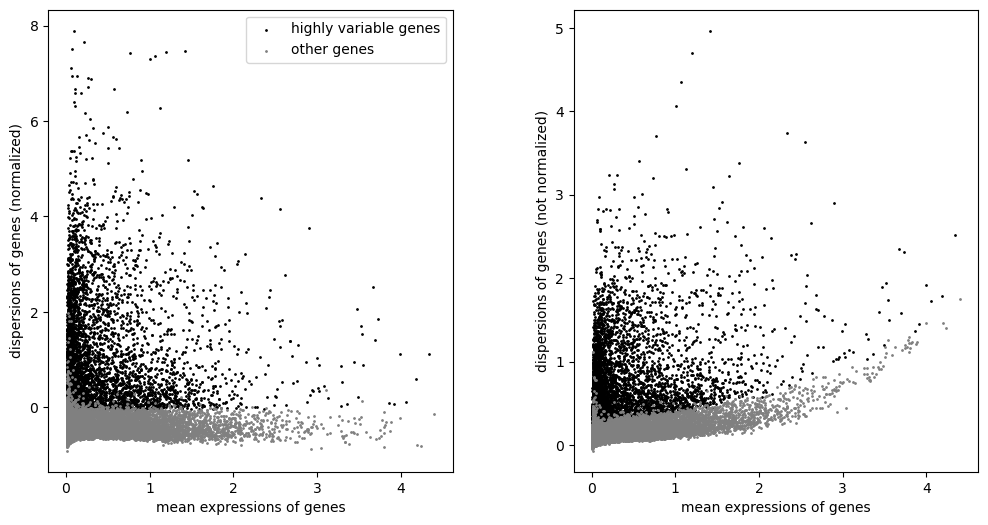

In [10]:
sc.pp.highly_variable_genes(subset, n_top_genes=5000, batch_key="stage")
sc.pl.highly_variable_genes(subset)
tdata.var["highly_variable"] = tdata.var_names.isin(subset.var_names[subset.var.highly_variable])

In [ ]:
hvg = subset.var.query("highly_variable").index.tolist()
pd.Series(hvg).to_csv(data_path / "hvg.csv", index=False, header = False)
pd.Series(use_genes).to_csv(data_path / "use_genes.csv", index=False, header = False)

## UMAP

In [ ]:
subset = tdata[:,tdata.var.highly_variable].copy()
rsc.get.anndata_to_GPU(subset)
rsc.tl.pca(subset, n_comps=50,use_highly_variable=False)
rsc.pp.neighbors(subset, n_neighbors=30, n_pcs=30)
rsc.tl.umap(subset, min_dist=.5, spread = .8)
tdata.obsm["X_umap"] = subset.obsm["X_umap"]
tdata.obsm["X_pca"] = subset.obsm["X_pca"]

/lab/solexa_weissman/wcolgan/tools/miniconda3/envs/rapids/lib/python3.12/site-packages/rapids_singlecell/preprocessing/_pca.py:140: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


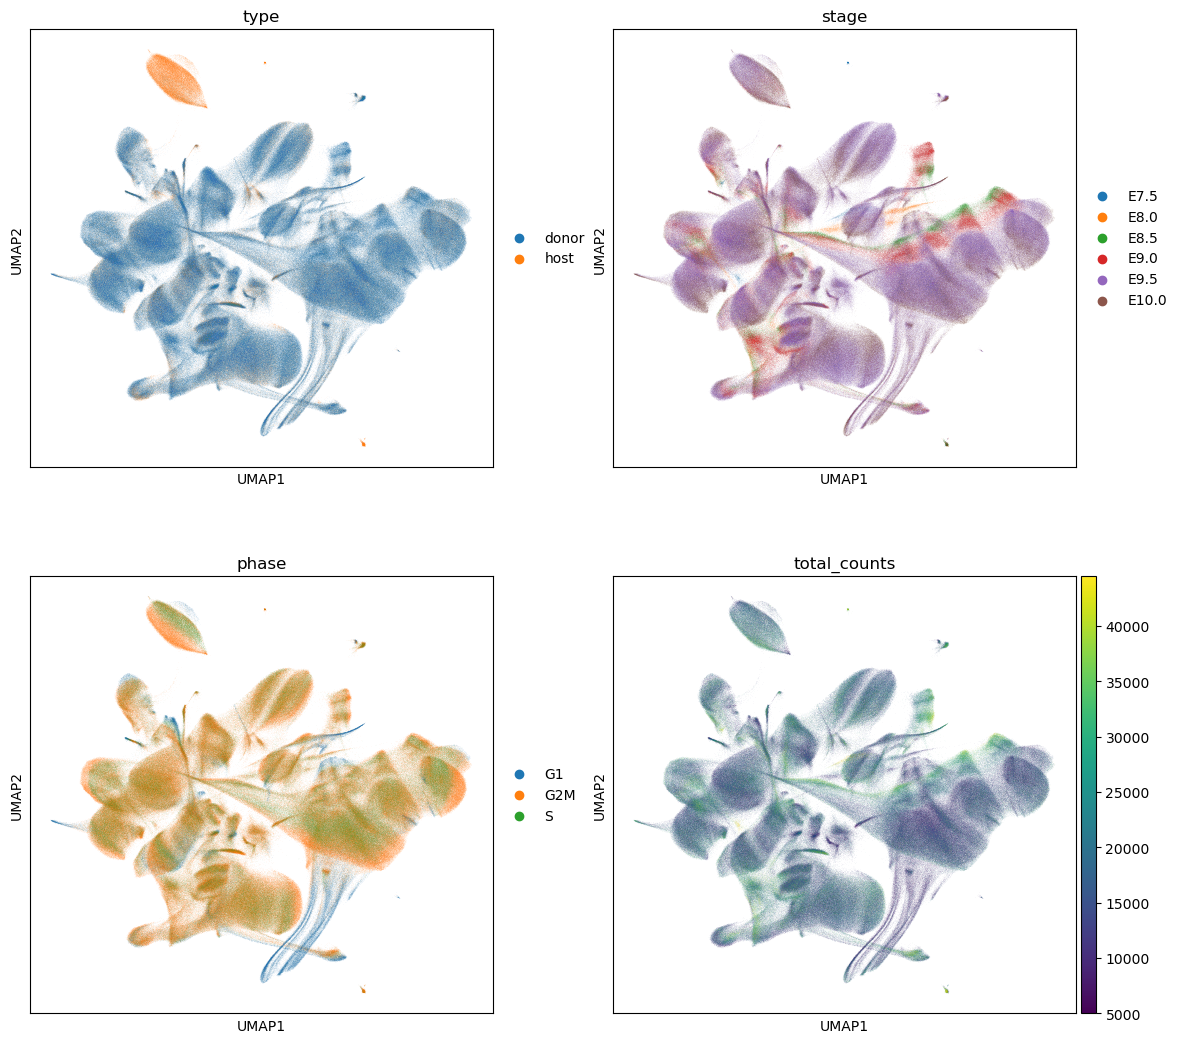

In [63]:
sc.pl.umap(tdata,  color=["type","stage","phase","total_counts"], ncols = 2, vmax = "p99")

## Label transfer

In [ ]:
labels = pd.read_csv(results_path / "label_transfer.csv", index_col=0)
tdata.obs = tdata.obs.merge(labels, left_index=True, right_index=True, how="left")

## Course clustering

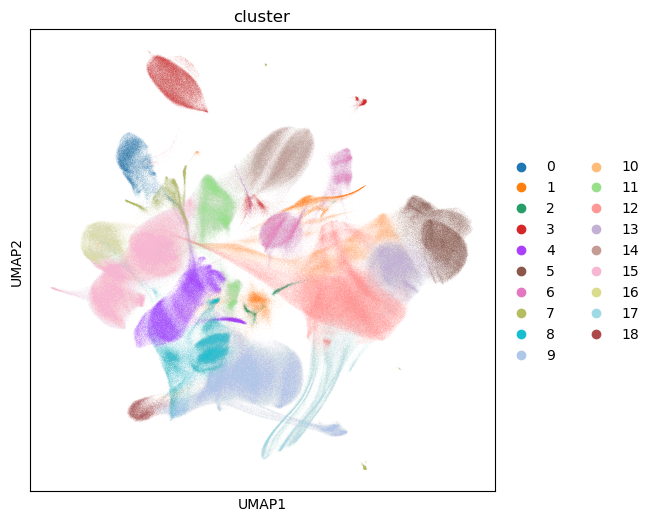

In [ ]:
rsc.tl.leiden(subset, resolution=0.3)
tdata.obs["cluster"] = tdata.obs["leiden"]
sc.pl.umap(tdata,color=["cluster"], ncols = 2, vmax = "p99")

In [ ]:
pd.DataFrame(tdata.obsm["X_umap"], index=tdata.obs_names, columns=["UMAP1","UMAP2"]).to_csv(
    "/lab/wcolgan_scratch/combined_umap.csv")
pd.DataFrame(subset.obsm["X_pca"], index=tdata.obs_names, columns=[f"PC{i}" for i in range(1,51)]).to_csv(
    "/lab/wcolgan_scratch/combined_pca.csv")
tdata.obs.to_csv("/lab/wcolgan_scratch/combined_obs.csv")

## Fine clustering

In [ ]:
subclusters = []
cluster_resolutions = {"0":0.4,"1":0.4,"2":0.45,"3":0.25,
    "4":0.2,"5":0.2,"6":0.2,"7":0.2,"8":0.2,"9":0.7,"10":0.2,"11":0.2,
    "12":0.3,"13":0.25,"14":0.25,"15":0.2,"16":0.2,"17":0.4,"18":0.1,"19":0.2}
for cluster, resolution in cluster_resolutions.items():
    print(f"Clustering {cluster} at resolution {resolution}")
    subset = tdata[tdata.obs.leiden == cluster].copy()
    sc.pp.highly_variable_genes(subset, n_top_genes=5000)
    subset.var.loc[~subset.var_names.isin(use_genes),"highly_variable"] = False
    rsc.pp.pca(subset, n_comps=30, mask_var = "highly_variable")
    rsc.pp.neighbors(subset, n_neighbors=15, n_pcs=30)
    rsc.tl.umap(subset)
    rsc.tl.leiden(subset, resolution=resolution, key_added="subcluster")
    sc.pl.umap(subset,color=["v2","subcluster"], ncols = 1, vmax = "p99")
    subclusters.append(subset.obs["subcluster"])
    subset.write_h5ad(f"/lab/wcolgan_scratch/{cluster}.h5ad")

In [ ]:
subclusters = pd.concat(subclusters, axis=0)
tdata.obs["subcluster"] = subclusters
tdata.obs["subcluster"] = tdata.obs["cluster"].astype(str) + "-" + tdata.obs["subcluster"].astype(str)
tdata.obs.to_csv("/lab/wcolgan_scratch/combined_obs.csv")

## Marker genes

In [ ]:
mean_expr = sc.get.aggregate(tdata, by=["subcluster"], func="mean")
mean_expr =pd.DataFrame(mean_expr.layers["mean"].T, index=mean_expr.var_names, columns=mean_expr.obs_names)
logfc_mat = mean_expr.sub(mean_expr.mean(axis=1), axis=0)

logfc = (
    logfc_mat
    .reset_index()
    .melt(id_vars="gene_name", var_name="subcluster", value_name="logfc")
    .merge(
        mean_expr.reset_index().melt(
            id_vars="gene_name",
            var_name="subcluster",
            value_name="mean"
        ),
        on=["gene_name", "subcluster"]
    )
)

# 2) Pearson correlation between subtypes based on logFC profiles
subtype_corr = logfc_mat.corr(method="pearson")

# 3) Find top 3 most similar subtypes for each subtype
top3_similar = {}
for subtype in subtype_corr.columns:
    top3 = (
        subtype_corr[subtype]
        .drop(index=subtype)          # remove self-correlation
        .sort_values(ascending=False)
        .head(3)
        .index
        .tolist()
    )
    top3_similar[subtype] = top3

# 4) Local logFC relative to the 3 most similar cell types
local_logfc_mat = pd.DataFrame(index=mean_expr.index, columns=mean_expr.columns, dtype=float)

for subtype in mean_expr.columns:
    neighbors = top3_similar[subtype]
    ref_expr = mean_expr[neighbors].mean(axis=1)
    local_logfc_mat[subtype] = mean_expr[subtype] - ref_expr

local_logfc = (
    local_logfc_mat
    .reset_index()
    .melt(id_vars="gene_name", var_name="subcluster", value_name="logfc")
    .merge(
        mean_expr.reset_index().melt(
            id_vars="gene_name",
            var_name="subcluster",
            value_name="mean"
        ),
        on=["gene_name", "subcluster"]
    )
)

In [ ]:
tdata.obs["n"] = 1
subclusters = tdata.obs.groupby("subcluster").agg({"n": "sum","time": "mean"}).reset_index()
for df, name in [(logfc, "global"), (local_logfc, "local")]:
    top_markers = (
        df.query("mean > .5")
        .sort_values(["subcluster", "logfc"], ascending=[True, False])
        .groupby("subcluster")
        .head(10)
        .groupby("subcluster")["gene_name"]
        .apply(lambda x: ", ".join(x))
        .reset_index(name=f"{name}_markers")
    )
    subclusters.drop(columns=[f"{name}_markers"], inplace=True, errors="ignore")
    subclusters = subclusters.merge(top_markers, on="subcluster")
subclusters["stages"] = subclusters["subcluster"].map(stage_representation)
subclusters.to_csv(results_path / "subclusters.csv", index=False)